# Mutual Fund Analytics — Fund Performance Analytics

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


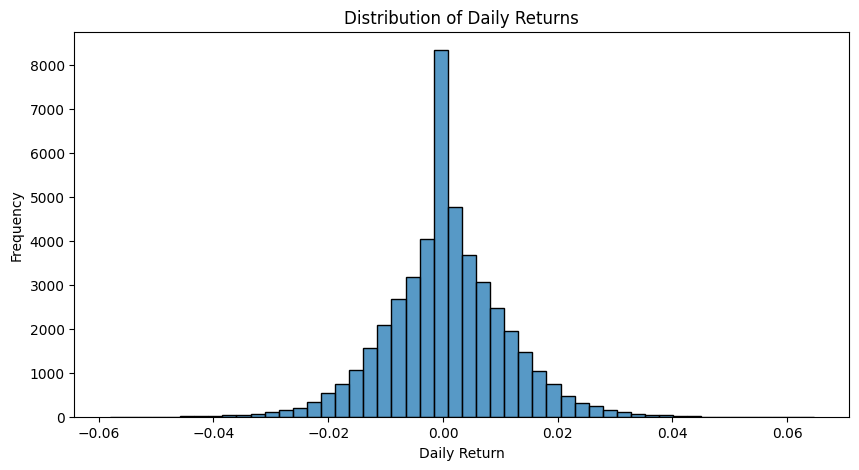

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Load NAV dataset
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Compute daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Display first rows
print(nav.head())

# Plot distribution of daily returns
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

### Insight:
Daily returns are concentrated around small values with occasional extreme movements, which is typical behavior for mutual fund NAV returns.

In [20]:
# CAGR calculation

cagr_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    start_nav = temp.iloc[0]["nav"]

    end_nav = temp.iloc[-1]["nav"]

    years = (
        (temp.iloc[-1]["date"] - temp.iloc[0]["date"]).days
    ) / 365

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_list.append([fund, cagr])

# Create dataframe
cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "cagr"]
)

# Convert to percentage
cagr_df["cagr_pct"] = cagr_df["cagr"] * 100

# Display output
print(cagr_df.head())

# Save file
cagr_df.to_csv("../reports/cagr_table.csv", index=False)

print("CAGR table saved successfully.")

   amfi_code      cagr   cagr_pct
0     100016  0.026352   2.635246
1     100025  0.044551   4.455091
2     100033  0.300997  30.099704
3     101206  0.235205  23.520489
4     101207  0.079331   7.933121
CAGR table saved successfully.


### Insight:
CAGR comparison shows long-term growth differences across mutual fund schemes, helping identify consistently performing funds.

# Sharpe Ratio Analysis

In [21]:
# Risk-free rate
rf = 0.065

# Sharpe ratio calculation
sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    mean_return = temp["daily_return"].mean() * 252

    std_return = temp["daily_return"].std() * np.sqrt(252)

    sharpe = (mean_return - rf) / std_return

    sharpe_list.append([fund, sharpe])

# Create dataframe
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

# Sort highest first
sharpe_df = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
)

# Display
print(sharpe_df.head())

# Save CSV
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

print("Sharpe ratio file saved successfully.")

    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101
Sharpe ratio file saved successfully.


### Insight:
Funds with higher Sharpe Ratios delivered better risk-adjusted returns, making them more efficient investment options.

# Sortino Ratio Analysis

In [22]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    mean_return = temp["daily_return"].mean() * 252

    downside = temp[temp["daily_return"] < 0]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    sortino = (mean_return - rf) / downside_std

    sortino_list.append([fund, sortino])

# Create dataframe
sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

# Sort descending
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

# Display
print(sortino_df.head())

# Save file
sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

print("Sortino ratio file saved successfully.")

    amfi_code  sortino_ratio
34     148567       2.385644
30     120843       2.364320
36     148569       2.146914
19     119551       2.140267
25     120505       2.029353
Sortino ratio file saved successfully.


### Insight:
Sortino Ratio analysis highlighted funds that managed downside risk more effectively while maintaining strong returns.

# Alpha and Beta Analysis

In [23]:
from scipy.stats import linregress

# Create benchmark using average market return
benchmark = nav.groupby("date")["daily_return"].mean()

alpha_beta_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    merged = pd.merge(
        temp[["date", "daily_return"]],
        benchmark.reset_index(),
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    merged = merged.dropna()

    # Regression
    slope, intercept, r_value, p_value, std_err = linregress(
        merged["daily_return_benchmark"],
        merged["daily_return_fund"]
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_list.append([
        fund,
        alpha,
        beta
    ])

# Create dataframe
alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=["amfi_code", "alpha", "beta"]
)

# Display
print(alpha_beta_df.head())

# Save file
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

print("Alpha-Beta file saved successfully.")

   amfi_code     alpha      beta
0     100016 -0.089699  0.788441
1     100025  0.033199  0.060713
2     100033  0.114423  0.991590
3     101206  0.097443  0.737015
4     101207 -0.350741  2.878184
Alpha-Beta file saved successfully.


### Insight:
Funds with positive alpha outperformed the benchmark on a risk-adjusted basis, while beta measured sensitivity to market movements.

# Maximum Drawdown Analysis

In [24]:
drawdown_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] / temp["running_max"]
    ) - 1

    max_drawdown = temp["drawdown"].min()

    drawdown_list.append([
        fund,
        max_drawdown
    ])

# Create dataframe
drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "max_drawdown"]
)

# Sort
drawdown_df = drawdown_df.sort_values(
    by="max_drawdown"
)

# Display
print(drawdown_df.head())

# Save file
drawdown_df.to_csv("../reports/max_drawdown.csv", index=False)

print("Maximum drawdown file saved successfully.")

    amfi_code  max_drawdown
22     119599     -0.525742
17     119095     -0.516778
4      101207     -0.354469
39     149324     -0.311719
21     119598     -0.287060
Maximum drawdown file saved successfully.


### Insight:
Maximum drawdown analysis identified the funds that experienced the largest declines from peak NAV levels during market downturns.

# Fund Scorecard

In [25]:
# Merge all analytics tables

scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

# Rank metrics
scorecard["return_rank"] = scorecard["cagr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=True)

# Composite score
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["drawdown_rank"] * 0.10
)

# Convert to 0–100 scale
scorecard["fund_score"] = (
    100 -
    (
        scorecard["fund_score"] /
        scorecard["fund_score"].max()
    ) * 100
)

# Sort best funds first
scorecard = scorecard.sort_values(
    by="fund_score",
    ascending=False
)

# Display top funds
print(scorecard.head())

# Save CSV
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved successfully.")

    amfi_code      cagr   cagr_pct  sharpe_ratio     alpha      beta  \
25     120505  0.328016  32.801599      1.180101  0.102647  1.194815   
34     148567  0.309499  30.949920      1.448291  0.181968  0.557134   
36     148569  0.319245  31.924486      1.234930  0.096473  1.174586   
30     120843  0.308833  30.883326      1.306744  0.102645  1.068746   
2      100033  0.300997  30.099704      1.093699  0.114423  0.991590   

    max_drawdown  return_rank  sharpe_rank  alpha_rank  drawdown_rank  \
25     -0.181885          1.0          5.0         5.0           16.0   
34     -0.112657          5.0          1.0         1.0           33.0   
36     -0.163967          4.0          3.0         8.0           20.0   
30     -0.129740          6.0          2.0         6.0           28.0   
2      -0.162172          7.0          7.0         4.0           21.0   

    fund_score  
25   85.590278  
34   81.770833  
36   80.729167  
30   78.125000  
2    76.562500  
Fund scorecard saved succe

### Insight:
The composite fund scorecard combined return, risk-adjusted performance, alpha generation, and drawdown control to identify the strongest mutual funds overall.

# Benchmark Comparison

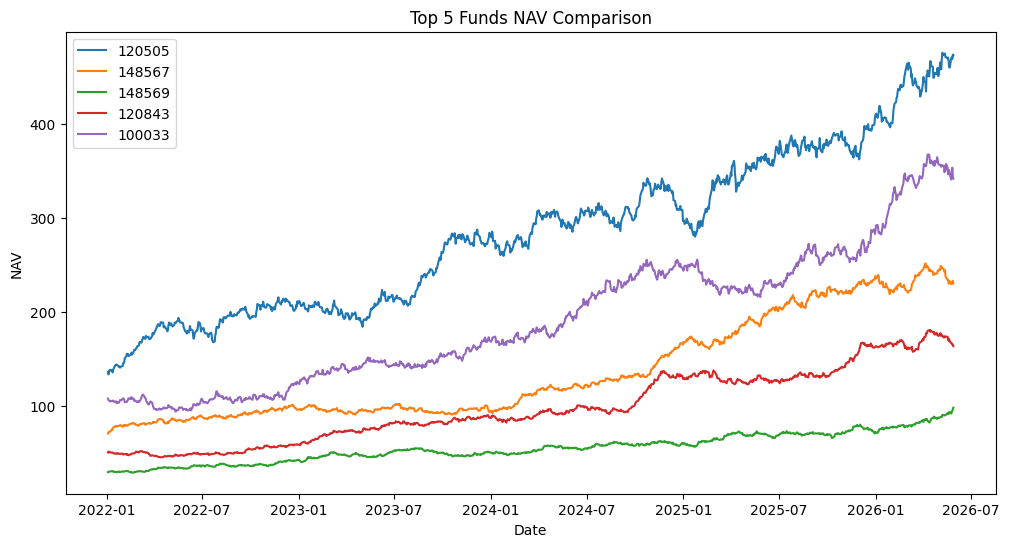

In [26]:
# Select top 5 funds
top_funds = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.show()

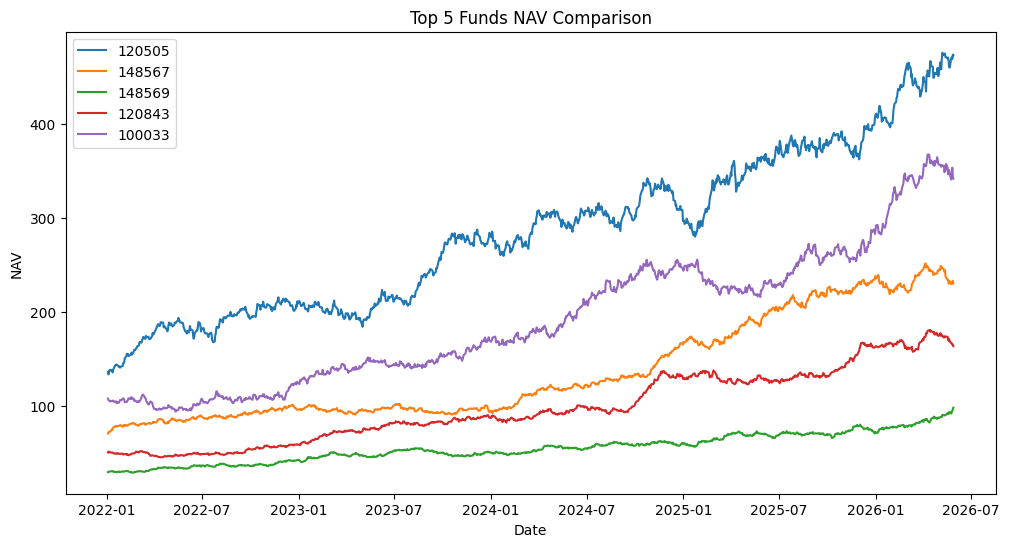

In [27]:
plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

### Insight:
Benchmark comparison revealed clear differences in NAV growth trajectories among the top-performing mutual funds over time.